In [ ]:
"""
auteur:Alexandre
date:2024/09/03
"""

# Première exploration des données en utilisant des graphiques simples

'\nauteur:Alexandre\ndate:2024/09/03\n'

# **Visualisation et Exploration**

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import params as prm
import pandas as pd
import numpy as np

## Résultats des élections

In [ ]:
# Chargement des données
df_1f = pd.read_csv(prm.datasets_pp_path / f"DF_{prm.dataset_1er_tour}.csv")
df_2f = pd.read_csv(prm.datasets_pp_path / f"DF_{prm.dataset_2nd_tour}.csv")
print(f"{df_1f.shape = }, {df_2f.shape = }")

df_1f.shape = (61593, 23), df_2f.shape = (61593, 18)


In [ ]:
# Normalisation des données
df_1f_norm = pd.DataFrame((df_1f[df_1f.keys()[:-2]].to_numpy().T / df_1f["Exprimés"].to_numpy()).T,
                           columns=df_1f.keys()[:-2])
df_2f_norm = pd.DataFrame((df_2f[df_2f.keys()[:-2]].to_numpy().T / df_2f["Exprimés"].to_numpy()).T,
                           columns=df_2f.keys()[:-2])
print(f"{df_1f_norm.shape = }, {df_2f_norm.shape = }")

df_1f_norm.shape = (61593, 21), df_2f_norm.shape = (61593, 16)


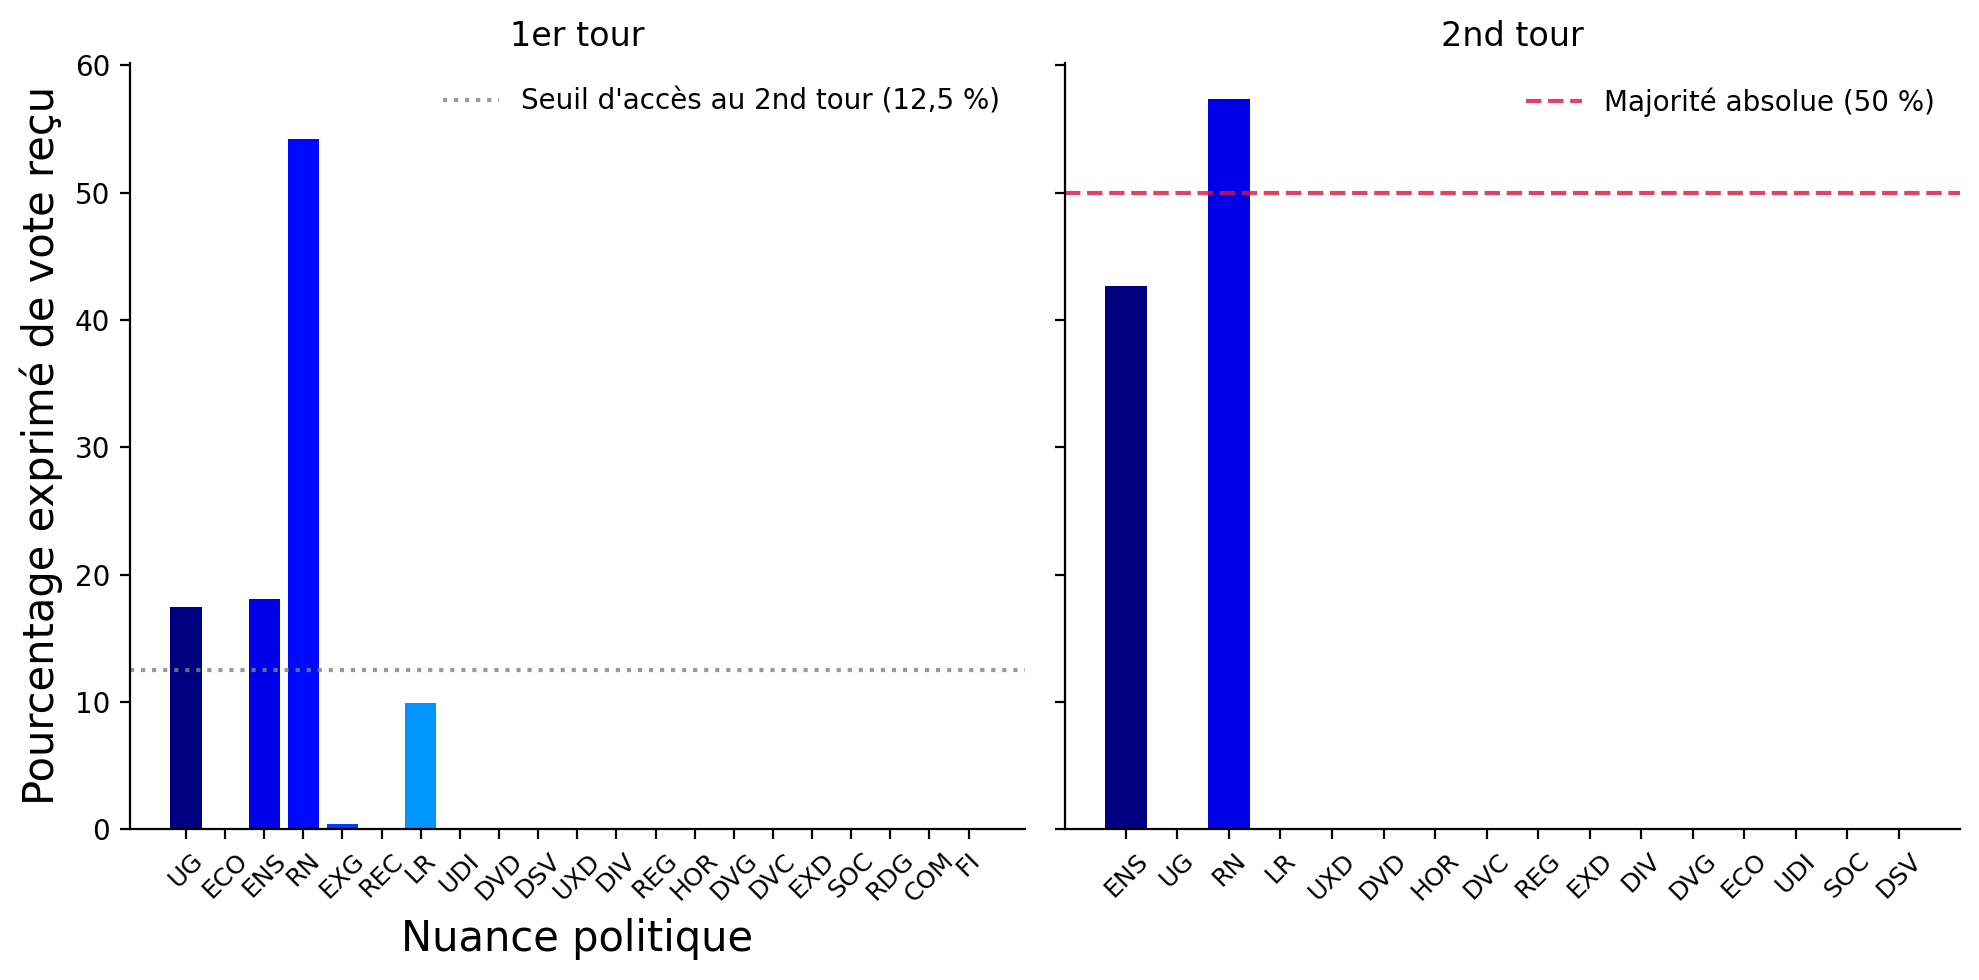

In [ ]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10,5),
    dpi=200, 
    sharey=True
)

ax[0].bar(
    x=df_1f_norm.keys(),
    height=df_1f_norm.iloc[:1].mean()*100,
    color=prm.cm_jet(np.linspace(0,1, len(df_1f.keys()))),
)

ax[1].bar(
    x=df_2f_norm.keys(),
    height=df_2f_norm.iloc[:1].mean()*100,
    color=prm.cm_jet(np.linspace(0,1, len(df_1f.keys())))
)

ax[0].set_xticks(
    df_1f_norm.keys(),
    df_1f_norm.keys(),
    rotation=45,
    size=9
)
ax[1].set_xticks(
    df_2f_norm.keys(),
    df_2f_norm.keys(),
    rotation=45,
    size=9
)

ax[0].set_xlabel("Nuance politique", size=15)
# ax[0].set_ylabel("Pourcentage moyen de vote reçu")
ax[0].set_ylabel("Pourcentage exprimé de vote reçu", size=15)

ax[0].set_title("1er tour")
ax[1].set_title("2nd tour")

ax[0].spines[["top","right"]].set_visible(False)
ax[1].spines[["top","right"]].set_visible(False)

ax[0].axhline(
    12.5,
    color="gray",
    linestyle=":",
    linewidth=1.5,
    alpha=0.8,
    label="Seuil d'accès au 2nd tour (12,5 %)"
)
ax[0].legend(frameon=False, loc="upper right")

ax[1].axhline(
    50,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    label="Majorité absolue (50 %)"
)
ax[1].legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig(
    prm.figures_path / "Distribution_votes_1er_et_2nd_tour.pdf",
    dpi=200
)
plt.show()

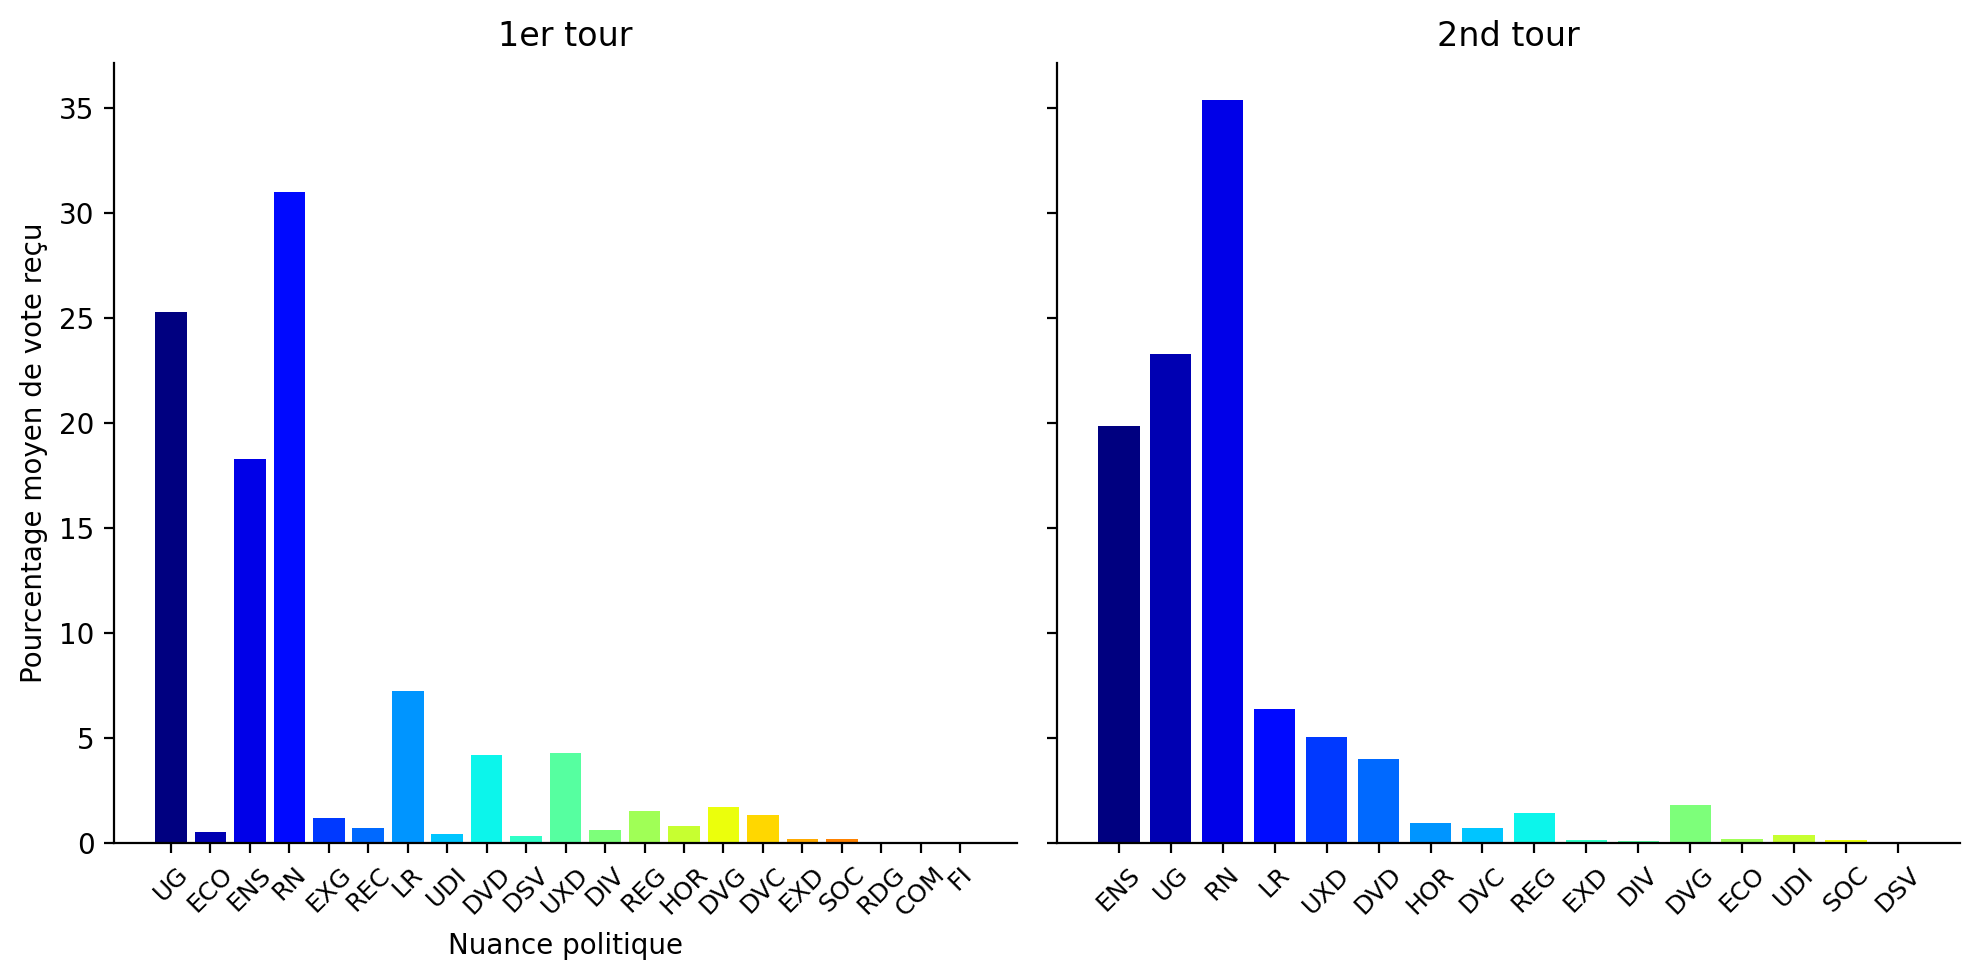

In [ ]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10,5),
    dpi=200, 
    sharey=True
)

ax[0].bar(
    x=df_1f_norm.keys(),
    height=df_1f_norm.mean()*100,
    color=prm.cm_jet(np.linspace(0,1, len(df_1f.keys()))),
)

ax[1].bar(
    x=df_2f_norm.keys(),
    height=df_2f_norm.mean()*100,
    color=prm.cm_jet(np.linspace(0,1, len(df_1f.keys())))
)

ax[0].set_xticks(
    df_1f_norm.keys(),
    df_1f_norm.keys(),
    rotation=45,
    size=9
)
ax[1].set_xticks(
    df_2f_norm.keys(),
    df_2f_norm.keys(),
    rotation=45,
    size=9
)

ax[0].set_xlabel("Nuance politique")
ax[0].set_ylabel("Pourcentage moyen de vote reçu")

ax[0].set_title("1er tour")
ax[1].set_title("2nd tour")

ax[0].spines[["top","right"]].set_visible(False)
ax[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(
    prm.figures_path / "Distribution_votes_1er_et_2nd_tour.pdf",
    dpi=200
)
plt.show()

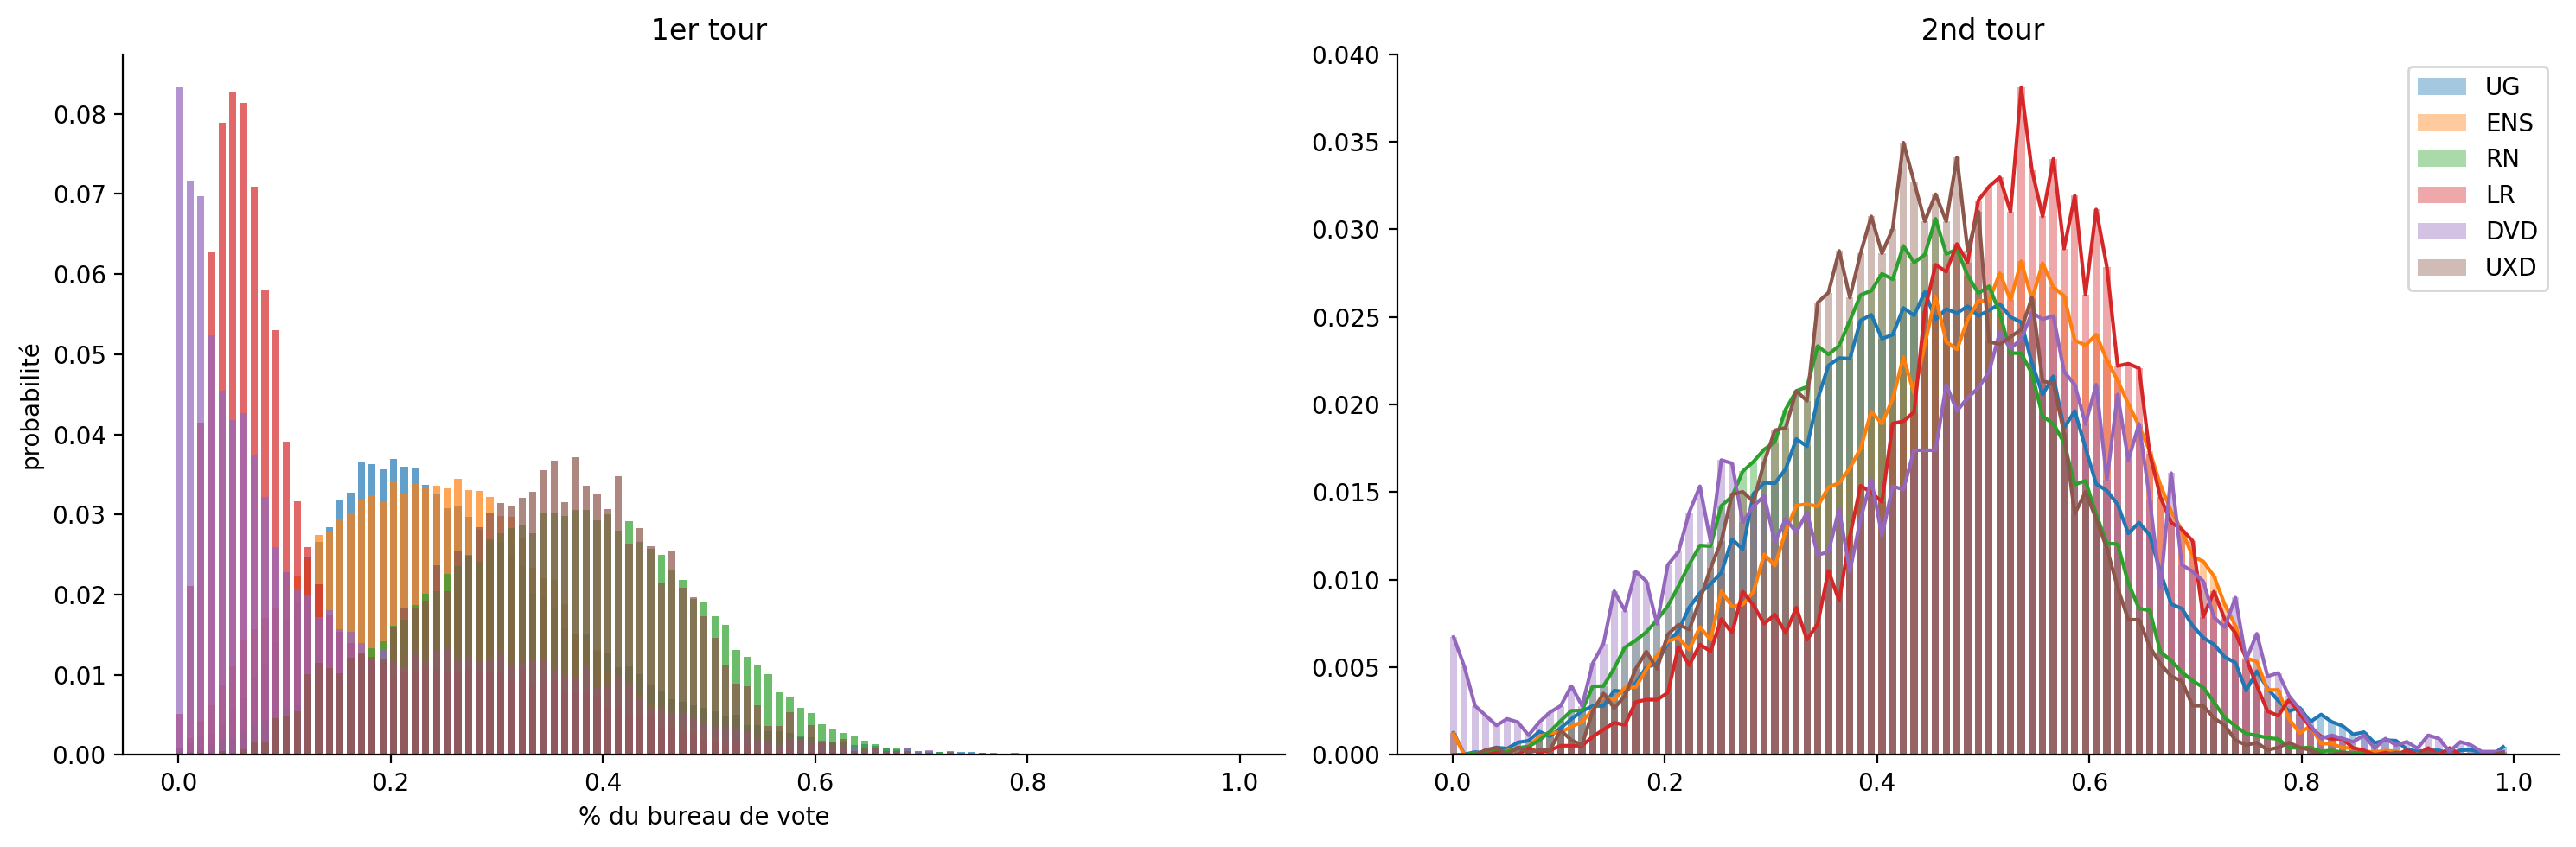

In [ ]:
fig,ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15,5),
    dpi=200
)

for grp in prm.Grandes_Nuances:
    
    to_plot = df_1f_norm[grp].to_numpy()

    values, bins = np.histogram(
        a=to_plot, bins=np.linspace(0.001, 1, 100)
    )

    ax[0].bar(
        x=bins[:-1],
        height=values/(values.sum()+1),
        width=(bins[1]-bins[0])/1.5,
        alpha=0.7, label=grp
    )

    to_plot = df_2f_norm[grp].to_numpy()

    values, bins = np.histogram(
        a=to_plot, bins=np.linspace(0.001, 1, 100)
    )

    ax[1].bar(
        x=bins[:-1],
        height=values/values.sum(),
        width=(bins[1]-bins[0])/1.5,
        alpha=0.4, label=grp
    )
    ax[1].plot(
        bins[:-1],
        values/values.sum(),
        alpha=1
    )

ax[0].set_title(" 1er tour")
ax[1].set_title(" 2nd tour")
ax[0].set_ylabel("probabilité")
ax[0].set_xlabel("% du bureau de vote")
ax[1].legend()

ax[0].spines[["top","right"]].set_visible(False)
ax[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(
    prm.figures_path / "Distribution_bv_1er_et_2nd_tour.pdf",
    dpi=200
)
plt.show()

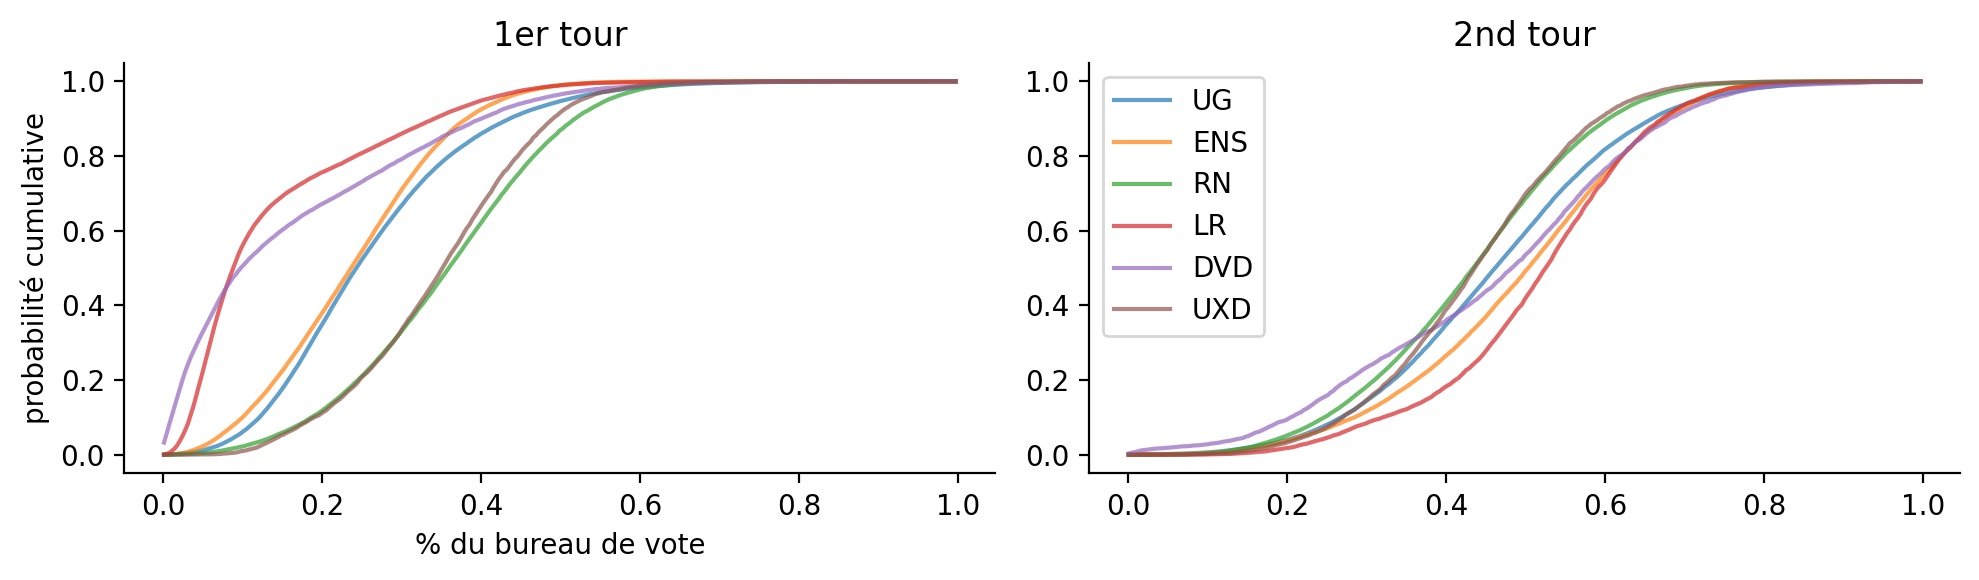

In [ ]:
fig,ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10,3),
    dpi=200
)

for grp in prm.Grandes_Nuances:
    
    to_plot = df_1f_norm[grp].to_numpy()

    values, bins = np.histogram(
        a=to_plot, bins=np.linspace(0.001, 1, 300)
    )

    ax[0].plot(
        bins[:-1],
        np.cumsum(values/(values.sum()+1)),
        alpha=0.7, label=grp
    )

    to_plot = df_2f_norm[grp].to_numpy()

    values, bins = np.histogram(
        a=to_plot, bins=np.linspace(0.001, 1, 300)
    )

    ax[1].plot(
        bins[:-1],
        np.cumsum(values/(values.sum()+1)),
        alpha=0.7, label=grp
    )

ax[0].set_title("1er tour")
ax[1].set_title("2nd tour")
ax[0].set_ylabel("probabilité cumulative")
ax[0].set_xlabel("% du bureau de vote")
ax[1].legend()

ax[0].spines[["top","right"]].set_visible(False)
ax[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(
    prm.figures_path / "Cumulative_bv_1er_et_2nd_tour.pdf",
    dpi=200
)
plt.show()

In [ ]:
prm.WaTer()

Last updated: 2026-07-21T13:28:11.396563+02:00

Python implementation: CPython
Python version       : 3.10.20
IPython version      : 8.37.0

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 7.0.0-27-generic
Machine     : x86_64
Processor   : inconnu
CPU cores   : 8
Architecture: 64bit

